# Purple Ball Tracking Control

This notebook builds on `test_camera.ipynb`: it keeps the same LAB threshold style you already used, then adds cleanup, contour filtering, confidence scoring, Kalman tracking, lost-ball recovery, and a debug overlay.

Possibilities with the current detection:

- **LAB thresholding** is the best first option because your existing calibration already produces purple ranges. Keep lighting and camera exposure fixed for stable results.
- **HSV thresholding** is available if LAB is too sensitive to brightness changes, especially when the ball is strongly saturated.
- **Shape filtering** removes purple objects that are not ball-like by checking circularity, area, radius, solidity, and fill ratio.
- **Confidence scoring** lets you rank multiple purple blobs instead of blindly choosing the biggest contour.
- **Kalman tracking** keeps a predicted position during short occlusions or motion blur.
- **Recovery mode** relaxes shape gates after several missed frames so the tracker can reacquire the ball.
- **Debug overlay** draws accepted and rejected candidates with the exact rejection reason.


In [1]:
from pathlib import Path
import sys
import threading
import time

import cv2
import numpy as np
from IPython.display import display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Install ipywidgets first: %pip install ipywidgets") from exc

try:
    import pyrealsense2 as rs2
except ImportError:
    rs2 = None

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import importlib
import purple_ball_tracker
importlib.reload(purple_ball_tracker)
from purple_ball_tracker import BallTrackerConfig, PurpleBallTracker, draw_debug_overlay, draw_path

print("Tracker helpers loaded from", PROJECT_DIR)


Tracker helpers loaded from /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final


## Camera Helpers

The RealSense path requests 60 FPS first, then falls back to lower FPS or smaller resolutions if the camera rejects the mode. A normal OpenCV webcam fallback is included for testing on another camera.


In [ ]:
from pathlib import Path
import sys
import time

import cv2
import numpy as np

try:
    import pyrealsense2 as rs2
except ImportError:
    rs2 = None

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings

_camera_live = globals().get("_camera_live", None)

# Change these before running the cell if you want to test a normal webcam instead.
CAMERA_CHECK_KIND = "webcam"  # "realsense" or "webcam"
CAMERA_CHECK_SERIAL = ""
CAMERA_CHECK_WEBCAM_INDEX = 0
CAMERA_CHECK_WIDTH = 640
CAMERA_CHECK_HEIGHT = 480
CAMERA_CHECK_FPS = 60
RUN_CAMERA_CHECK_NOW = True


def stop_tracker_preview(silent=False):
    global _camera_live
    if _camera_live is not None:
        _camera_live["running"] = False
        source = _camera_live.get("source")
        close_camera_source(source, silent=True)
        _camera_live = None
    if not silent:
        print("Tracker preview stopped.")


def _candidate_realsense_modes(width=640, height=480, fps=60):
    requested = [(width, height, fps)]
    fallbacks = [(640, 480, 60), (640, 480, 30), (640, 480, 15), (424, 240, 60), (424, 240, 30), (320, 240, 60), (320, 240, 30)]
    seen = []
    for mode in requested + fallbacks:
        if mode not in seen:
            seen.append(mode)
            yield mode


def _device_info(device, key, fallback="unknown"):
    try:
        if device.supports(key):
            return device.get_info(key)
    except Exception:
        pass
    return fallback


def print_realsense_devices():
    if rs2 is None:
        print("RealSense SDK: not installed in this kernel.")
        return []

    ctx = rs2.context()
    devices = list(ctx.query_devices())
    print(f"RealSense SDK: available, devices found: {len(devices)}")
    for index, device in enumerate(devices):
        name = _device_info(device, rs2.camera_info.name)
        serial = _device_info(device, rs2.camera_info.serial_number)
        firmware = _device_info(device, rs2.camera_info.firmware_version)
        usb = _device_info(device, rs2.camera_info.usb_type_descriptor)
        product_line = _device_info(device, rs2.camera_info.product_line)
        sensor_names = []
        for sensor in device.query_sensors():
            try:
                sensor_names.append(sensor.get_info(rs2.camera_info.name))
            except Exception:
                sensor_names.append("unnamed sensor")
        print(f"  [{index}] {name} serial={serial} product_line={product_line} firmware={firmware} usb={usb}")
        print("      sensors:", ", ".join(sensor_names) if sensor_names else "none reported")
    return devices


def describe_camera_source(source):
    if source["kind"] == "realsense":
        print(
            "Connected camera source: RealSense via pyrealsense2 "
            f"| mode={source['width']}x{source['height']} @ {source['fps']} FPS "
            f"| color_format={source['format']}"
        )
    elif source["kind"] == "webcam":
        capture = source["capture"]
        try:
            backend = capture.getBackendName()
        except Exception:
            backend = "unknown backend"
        actual_width = capture.get(cv2.CAP_PROP_FRAME_WIDTH)
        actual_height = capture.get(cv2.CAP_PROP_FRAME_HEIGHT)
        actual_fps = capture.get(cv2.CAP_PROP_FPS)
        print(
            "Connected camera source: OpenCV VideoCapture "
            f"| index={source['index']} | backend={backend} "
            f"| mode={actual_width:.0f}x{actual_height:.0f} @ {actual_fps:.1f} FPS"
        )
    else:
        print(f"Connected camera source: {source}")


def start_realsense_source(serial="", width=640, height=480, fps=60):
    if rs2 is None:
        raise ImportError("pyrealsense2 is not installed. Use camera='webcam' or install pyrealsense2.")

    print_realsense_devices()
    errors = []
    for mode_width, mode_height, mode_fps in _candidate_realsense_modes(width, height, fps):
        for color_format, format_name in [(rs2.format.rgb8, "rgb8"), (rs2.format.bgr8, "bgr8")]:
            print(f"Trying RealSense color stream: {mode_width}x{mode_height} @ {mode_fps} FPS ({format_name})")
            pipeline = rs2.pipeline()
            config = rs2.config()
            keep_pipeline = False
            if serial:
                config.enable_device(serial)
            config.enable_stream(rs2.stream.color, mode_width, mode_height, color_format, mode_fps)
            try:
                pipeline.start(config)
                deadline = time.time() + 4.0
                while time.time() < deadline:
                    ok, _ = read_camera_frame({"kind": "realsense", "pipeline": pipeline, "format": format_name}, timeout_ms=500)
                    if ok:
                        keep_pipeline = True
                        source = {"kind": "realsense", "pipeline": pipeline, "format": format_name, "width": mode_width, "height": mode_height, "fps": mode_fps}
                        describe_camera_source(source)
                        return source
                errors.append(f"{mode_width}x{mode_height}@{mode_fps} {format_name}: opened but no frames")
            except RuntimeError as exc:
                errors.append(f"{mode_width}x{mode_height}@{mode_fps} {format_name}: {exc}")
            finally:
                if not keep_pipeline:
                    try:
                        pipeline.stop()
                    except Exception:
                        pass
    raise RuntimeError("Could not start RealSense color stream. Tried:\n" + "\n".join(errors))


def start_webcam_source(index=0, width=640, height=480, fps=60):
    print(f"Trying OpenCV webcam index {index}: requested {width}x{height} @ {fps} FPS")
    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")
    saved_settings = load_camera_settings()
    if saved_settings:
        print(f"Saved camera settings found: {SETTINGS_PATH}")
        apply_webcam_settings(capture, saved_settings, verbose=True)
        time.sleep(0.3)
    else:
        print(f"No saved camera settings found at {SETTINGS_PATH}; using current camera defaults.")
    source = {"kind": "webcam", "capture": capture, "index": index, "width": width, "height": height, "fps": fps}
    describe_camera_source(source)
    return source


def read_camera_frame(source, timeout_ms=1000):
    if source["kind"] == "realsense":
        try:
            frames = source["pipeline"].wait_for_frames(timeout_ms)
        except RuntimeError:
            return False, None
        color_frame = frames.get_color_frame()
        if not color_frame:
            return False, None
        frame = np.asanyarray(color_frame.get_data())
        if source.get("format") == "bgr8":
            return True, frame
        return True, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    if source["kind"] == "webcam":
        return source["capture"].read()

    raise ValueError(f"Unknown camera source: {source['kind']}")


def close_camera_source(source, silent=False):
    if not source:
        return
    try:
        if source.get("kind") == "realsense":
            source["pipeline"].stop()
        elif source.get("kind") == "webcam":
            source["capture"].release()
    except Exception as exc:
        if not silent:
            print(f"Camera close warning: {exc}")


def show_frame_preview(frame, title="Camera preview"):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ok, encoded = cv2.imencode(".jpg", rgb, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
    if not ok:
        raise RuntimeError("Could not encode preview frame.")
    try:
        from IPython.display import Image, display
        display(Image(data=encoded.tobytes(), format="jpeg"))
    except Exception:
        preview_path = Path("camera_preview.jpg")
        cv2.imwrite(str(preview_path), frame)
        print(f"{title} saved to {preview_path.resolve()}")


def camera_connection_check(camera="realsense", serial="", webcam_index=0, width=640, height=480, fps=60, preview=True, sample_frames=30):
    source = None
    try:
        source = start_camera_source(camera=camera, serial=serial, webcam_index=webcam_index, width=width, height=height, fps=fps)
        first_frame = None
        frames_read = 0
        t0 = time.perf_counter()
        deadline = time.time() + 5.0
        while frames_read < sample_frames and time.time() < deadline:
            ok, frame = read_camera_frame(source, timeout_ms=500)
            if not ok:
                continue
            if first_frame is None:
                first_frame = frame.copy()
            frames_read += 1
        elapsed = max(1e-6, time.perf_counter() - t0)
        measured_fps = frames_read / elapsed
        if first_frame is None:
            raise RuntimeError("Camera opened, but no preview frame was received.")
        check = {
            "camera": camera,
            "requested_width": width,
            "requested_height": height,
            "requested_fps": fps,
            "source_kind": source.get("kind"),
            "source_width": source.get("width"),
            "source_height": source.get("height"),
            "source_fps": source.get("fps"),
            "source_format": source.get("format"),
            "webcam_index": source.get("index"),
            "frames_read": frames_read,
            "elapsed_s": elapsed,
            "measured_fps": measured_fps,
            "frame_shape": first_frame.shape,
            "frame_dtype": str(first_frame.dtype),
        }
        if source.get("kind") == "webcam":
            capture = source["capture"]
            try:
                check["backend"] = capture.getBackendName()
            except Exception:
                check["backend"] = "unknown"
            check["actual_width"] = capture.get(cv2.CAP_PROP_FRAME_WIDTH)
            check["actual_height"] = capture.get(cv2.CAP_PROP_FRAME_HEIGHT)
            check["actual_fps"] = capture.get(cv2.CAP_PROP_FPS)
        globals()["LAST_CAMERA_CHECK"] = check
        print(f"Frame check: received {frames_read} frames in {elapsed:.2f}s, measured loop rate {measured_fps:.1f} FPS")
        print(f"Preview frame: shape={first_frame.shape}, dtype={first_frame.dtype}")
        if preview:
            show_frame_preview(first_frame)
        print("Saved LAST_CAMERA_CHECK for the calibration/control cell.")
        print("Camera check OK. The stream was closed after the preview check.")
        return first_frame
    finally:
        close_camera_source(source, silent=True)


def start_camera_source(camera="realsense", serial="", webcam_index=0, width=640, height=480, fps=60):
    if camera == "realsense":
        return start_realsense_source(serial=serial, width=width, height=height, fps=fps)
    if camera == "webcam":
        return start_webcam_source(index=webcam_index, width=width, height=height, fps=fps)
    raise ValueError("camera must be 'realsense' or 'webcam'")


if RUN_CAMERA_CHECK_NOW:
    camera_connection_check(
        camera=CAMERA_CHECK_KIND,
        serial=CAMERA_CHECK_SERIAL,
        webcam_index=CAMERA_CHECK_WEBCAM_INDEX,
        width=CAMERA_CHECK_WIDTH,
        height=CAMERA_CHECK_HEIGHT,
        fps=CAMERA_CHECK_FPS,
        preview=True,
    )


## Camera Exposure Reset

Run this cell if the image becomes too bright or too dark after changing exposure controls. It restores auto exposure and auto white balance where the camera backend allows it, prints the before/after control values, and shows a fresh preview frame.


Resetting OpenCV webcam index=0 backend=V4L2
Before reset:
  AUTO_EXPOSURE: 3.000
  EXPOSURE: 1250.000
  GAIN: -1.000
  AUTO_WB: 1.000
  WB_TEMPERATURE: 4500.000
  BRIGHTNESS: 102.000
  CONTRAST: 27.000
Applying auto exposure / auto white balance:
  AUTO_EXPOSURE: before=3.000 requested=3.000 after=3.000 set_ok=True
  AUTO_WB: before=1.000 requested=1.000 after=1.000 set_ok=True
  GAIN: before=-1.000 requested=0.000 after=-1.000 set_ok=False
After reset:
  AUTO_EXPOSURE: 3.000
  EXPOSURE: 1250.000
  GAIN: -1.000
  AUTO_WB: 1.000
  WB_TEMPERATURE: 4500.000
Letting auto controls settle for 1.5s...
Preview frame after reset: shape=(480, 640, 3), dtype=uint8, frames_read=30


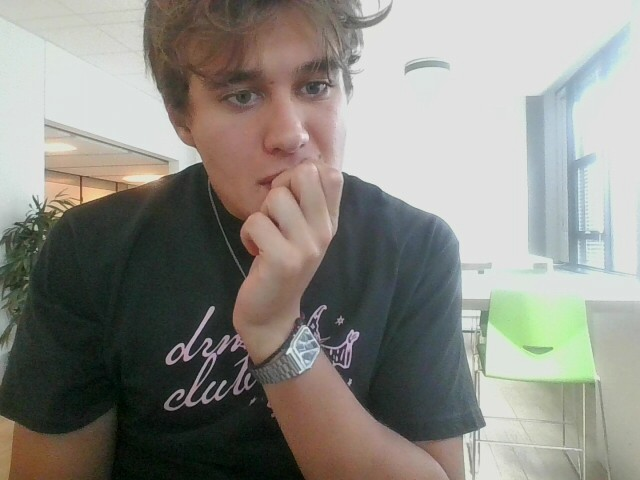

In [2]:
from pathlib import Path
import time

import cv2
import numpy as np
from IPython.display import Image, display

try:
    import pyrealsense2 as rs2
except ImportError:
    rs2 = None

RESET_CAMERA_KIND = globals().get("CAMERA_CHECK_KIND", "webcam")
RESET_WEBCAM_INDEX = globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)
RESET_WIDTH = globals().get("CAMERA_CHECK_WIDTH", 640)
RESET_HEIGHT = globals().get("CAMERA_CHECK_HEIGHT", 480)
RESET_FPS = globals().get("CAMERA_CHECK_FPS", 30)
RESET_REALSENSE_SERIAL = globals().get("CAMERA_CHECK_SERIAL", "")
RUN_CAMERA_EXPOSURE_RESET_NOW = True


def _show_bgr_preview(frame, title="Camera reset preview"):
    ok, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
    if not ok:
        raise RuntimeError("Could not encode preview frame.")
    display(Image(data=encoded.tobytes(), format="jpeg"))


def _opencv_prop_report(capture, label, prop_id):
    try:
        value = capture.get(prop_id)
        print(f"  {label}: {value:.3f}")
        return value
    except Exception as exc:
        print(f"  {label}: unavailable ({exc})")
        return None


def _opencv_set_and_report(capture, label, prop_id, value):
    before = capture.get(prop_id)
    ok = capture.set(prop_id, float(value))
    time.sleep(0.05)
    after = capture.get(prop_id)
    print(f"  {label}: before={before:.3f} requested={float(value):.3f} after={after:.3f} set_ok={ok}")


def reset_webcam_to_auto(index=0, width=640, height=480, fps=30, preview=True):
    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")

    try:
        try:
            backend = capture.getBackendName()
        except Exception:
            backend = "unknown"
        print(f"Resetting OpenCV webcam index={index} backend={backend}")
        print("Before reset:")
        _opencv_prop_report(capture, "AUTO_EXPOSURE", getattr(cv2, "CAP_PROP_AUTO_EXPOSURE", cv2.CAP_PROP_EXPOSURE))
        _opencv_prop_report(capture, "EXPOSURE", cv2.CAP_PROP_EXPOSURE)
        _opencv_prop_report(capture, "GAIN", cv2.CAP_PROP_GAIN)
        if hasattr(cv2, "CAP_PROP_AUTO_WB"):
            _opencv_prop_report(capture, "AUTO_WB", cv2.CAP_PROP_AUTO_WB)
        if hasattr(cv2, "CAP_PROP_WB_TEMPERATURE"):
            _opencv_prop_report(capture, "WB_TEMPERATURE", cv2.CAP_PROP_WB_TEMPERATURE)
        _opencv_prop_report(capture, "BRIGHTNESS", cv2.CAP_PROP_BRIGHTNESS)
        _opencv_prop_report(capture, "CONTRAST", cv2.CAP_PROP_CONTRAST)

        print("Applying auto exposure / auto white balance:")
        if hasattr(cv2, "CAP_PROP_AUTO_EXPOSURE"):
            # V4L2 usually uses 3.0 for aperture-priority auto exposure and 1.0 for manual.
            _opencv_set_and_report(capture, "AUTO_EXPOSURE", cv2.CAP_PROP_AUTO_EXPOSURE, 3.0)
        if hasattr(cv2, "CAP_PROP_AUTO_WB"):
            _opencv_set_and_report(capture, "AUTO_WB", cv2.CAP_PROP_AUTO_WB, 1.0)
        _opencv_set_and_report(capture, "GAIN", cv2.CAP_PROP_GAIN, 0.0)

        print("After reset:")
        _opencv_prop_report(capture, "AUTO_EXPOSURE", getattr(cv2, "CAP_PROP_AUTO_EXPOSURE", cv2.CAP_PROP_EXPOSURE))
        _opencv_prop_report(capture, "EXPOSURE", cv2.CAP_PROP_EXPOSURE)
        _opencv_prop_report(capture, "GAIN", cv2.CAP_PROP_GAIN)
        if hasattr(cv2, "CAP_PROP_AUTO_WB"):
            _opencv_prop_report(capture, "AUTO_WB", cv2.CAP_PROP_AUTO_WB)
        if hasattr(cv2, "CAP_PROP_WB_TEMPERATURE"):
            _opencv_prop_report(capture, "WB_TEMPERATURE", cv2.CAP_PROP_WB_TEMPERATURE)

        print("Letting auto controls settle for 1.5s...")
        time.sleep(1.5)
        frame = None
        frames_read = 0
        deadline = time.time() + 4.0
        while time.time() < deadline and frames_read < 30:
            ok, candidate = capture.read()
            if ok:
                frame = candidate
                frames_read += 1
        if frame is None:
            raise RuntimeError("Camera opened, but no frame was received after reset.")
        print(f"Preview frame after reset: shape={frame.shape}, dtype={frame.dtype}, frames_read={frames_read}")
        if preview:
            _show_bgr_preview(frame)
        return frame
    finally:
        capture.release()


def reset_realsense_to_auto(serial="", width=640, height=480, fps=30, preview=True):
    if rs2 is None:
        raise ImportError("pyrealsense2 is not installed in this kernel.")
    pipeline = rs2.pipeline()
    config = rs2.config()
    if serial:
        config.enable_device(serial)
    config.enable_stream(rs2.stream.color, width, height, rs2.format.bgr8, fps)
    try:
        profile = pipeline.start(config)
        device = profile.get_device()
        color_sensor = None
        for sensor in device.query_sensors():
            name = sensor.get_info(rs2.camera_info.name).lower()
            if "rgb" in name or "color" in name:
                color_sensor = sensor
                break
        if color_sensor is None:
            raise RuntimeError("Could not find RealSense color sensor.")
        print("Resetting RealSense color sensor to auto controls")
        for option, label, value in [
            (rs2.option.enable_auto_exposure, "AUTO_EXPOSURE", 1.0),
            (rs2.option.enable_auto_white_balance, "AUTO_WB", 1.0),
        ]:
            if color_sensor.supports(option):
                before = color_sensor.get_option(option)
                color_sensor.set_option(option, value)
                after = color_sensor.get_option(option)
                print(f"  {label}: before={before:.3f} requested={value:.3f} after={after:.3f}")
            else:
                print(f"  {label}: not supported")
        print("Letting auto controls settle for 1.5s...")
        time.sleep(1.5)
        frame = None
        for _ in range(30):
            frames = pipeline.wait_for_frames(1000)
            color_frame = frames.get_color_frame()
            if color_frame:
                frame = np.asanyarray(color_frame.get_data()).copy()
        if frame is None:
            raise RuntimeError("No RealSense color frame received after reset.")
        print(f"Preview frame after reset: shape={frame.shape}, dtype={frame.dtype}")
        if preview:
            _show_bgr_preview(frame)
        return frame
    finally:
        pipeline.stop()


def reset_camera_exposure_to_auto(camera=RESET_CAMERA_KIND):
    if camera == "webcam":
        return reset_webcam_to_auto(
            index=RESET_WEBCAM_INDEX,
            width=RESET_WIDTH,
            height=RESET_HEIGHT,
            fps=RESET_FPS,
            preview=True,
        )
    if camera == "realsense":
        return reset_realsense_to_auto(
            serial=RESET_REALSENSE_SERIAL,
            width=RESET_WIDTH,
            height=RESET_HEIGHT,
            fps=RESET_FPS,
            preview=True,
        )
    raise ValueError("camera must be 'webcam' or 'realsense'")


if RUN_CAMERA_EXPOSURE_RESET_NOW:
    LAST_RESET_FRAME = reset_camera_exposure_to_auto()


## Live Camera Control Panel

Use this before color calibration. Keep room lighting fixed, tune the camera until the ball is visible without overexposure, then lock exposure/white balance for stable LAB values.


In [1]:
from pathlib import Path
import sys
import threading
import time

import cv2
from IPython.display import display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Install ipywidgets first: %pip install ipywidgets") from exc

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from camera_settings import SETTINGS_PATH, load_camera_settings, save_camera_settings

CAMERA_CONTROL_KIND = globals().get("CAMERA_CHECK_KIND", "webcam")
CAMERA_CONTROL_WEBCAM_INDEX = globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)
CAMERA_CONTROL_WIDTH = globals().get("CAMERA_CHECK_WIDTH", 640)
CAMERA_CONTROL_HEIGHT = globals().get("CAMERA_CHECK_HEIGHT", 480)
CAMERA_CONTROL_FPS = globals().get("CAMERA_CHECK_FPS", 30)
RUN_CAMERA_CONTROL_PANEL_NOW = True

_camera_control = globals().get("_camera_control", None)


def stop_camera_control_panel(_=None, silent=False):
    global _camera_control
    if _camera_control is not None:
        _camera_control["running"] = False
        capture = _camera_control.get("capture")
        if capture is not None:
            try:
                capture.release()
            except Exception:
                pass
        _camera_control = None
    if not silent:
        print("Camera control panel stopped.")


def _prop_supported(prop_id):
    return prop_id is not None and prop_id >= 0


def _get_prop(capture, prop_id):
    if not _prop_supported(prop_id):
        return None
    try:
        return capture.get(prop_id)
    except Exception:
        return None


def _set_prop(capture, prop_id, value):
    if not _prop_supported(prop_id):
        return False, None, None
    before = _get_prop(capture, prop_id)
    try:
        ok = capture.set(prop_id, float(value))
    except Exception:
        ok = False
    time.sleep(0.03)
    after = _get_prop(capture, prop_id)
    return ok, before, after


def _fmt(value):
    if value is None:
        return "n/a"
    return f"{value:.3f}"


def _open_control_webcam(index, width, height, fps):
    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")
    try:
        backend = capture.getBackendName()
    except Exception:
        backend = "unknown"
    print(f"Camera control connected: OpenCV webcam index={index} backend={backend}")
    print(f"Requested mode: {width}x{height} @ {fps} FPS")
    print(f"Reported mode: {capture.get(cv2.CAP_PROP_FRAME_WIDTH):.0f}x{capture.get(cv2.CAP_PROP_FRAME_HEIGHT):.0f} @ {capture.get(cv2.CAP_PROP_FPS):.1f} FPS")
    return capture


def camera_control_panel(index=CAMERA_CONTROL_WEBCAM_INDEX, width=CAMERA_CONTROL_WIDTH, height=CAMERA_CONTROL_HEIGHT, fps=CAMERA_CONTROL_FPS):
    global _camera_control
    if CAMERA_CONTROL_KIND != "webcam":
        raise NotImplementedError("This control panel currently targets the OpenCV/V4L2 webcam path. Set CAMERA_CONTROL_KIND='webcam'.")

    stop_camera_control_panel(silent=True)
    capture = _open_control_webcam(index, width, height, fps)

    image = widgets.Image(format="jpeg", width=width, height=height)
    status = widgets.HTML(value="<span>Camera control running.</span>")
    log = widgets.Output()

    saved_settings = load_camera_settings() or {}
    if saved_settings:
        print(f"Loaded persisted camera settings from {SETTINGS_PATH}")
    auto_exposure = widgets.Checkbox(value=bool(saved_settings.get("auto_exposure", True)), description="Auto exposure", indent=False)
    exposure = widgets.FloatSlider(value=float(saved_settings.get("exposure", -6.0) or -6.0), min=-13.0, max=0.0, step=0.5, description="Exposure", continuous_update=False)
    gain = widgets.FloatSlider(value=float(saved_settings.get("gain", 0.0) or 0.0), min=0.0, max=255.0, step=1.0, description="Gain", continuous_update=False)
    auto_wb = widgets.Checkbox(value=bool(saved_settings.get("auto_wb", True)), description="Auto WB", indent=False)
    wb_temp = widgets.IntSlider(value=int(saved_settings.get("white_balance", 4500) or 4500), min=2800, max=6500, step=100, description="WB temp", continuous_update=False)
    brightness = widgets.FloatSlider(value=float(saved_settings.get("brightness", _get_prop(capture, cv2.CAP_PROP_BRIGHTNESS) or 0.0) or 0.0), min=0.0, max=255.0, step=1.0, description="Brightness", continuous_update=False)
    contrast = widgets.FloatSlider(value=float(saved_settings.get("contrast", _get_prop(capture, cv2.CAP_PROP_CONTRAST) or 0.0) or 0.0), min=0.0, max=255.0, step=1.0, description="Contrast", continuous_update=False)
    saturation = widgets.FloatSlider(value=float(saved_settings.get("saturation", _get_prop(capture, cv2.CAP_PROP_SATURATION) or 0.0) or 0.0), min=0.0, max=255.0, step=1.0, description="Saturation", continuous_update=False)

    apply_button = widgets.Button(description="Apply controls", button_style="primary")
    read_button = widgets.Button(description="Read values")
    stop_button = widgets.Button(description="Stop camera", button_style="danger")
    save_button = widgets.Button(description="Save settings")

    def read_values(_=None):
        with log:
            print("Camera values reported now:")
            print(f"  AUTO_EXPOSURE={_fmt(_get_prop(capture, getattr(cv2, 'CAP_PROP_AUTO_EXPOSURE', -1)))}")
            print(f"  EXPOSURE={_fmt(_get_prop(capture, cv2.CAP_PROP_EXPOSURE))}")
            print(f"  GAIN={_fmt(_get_prop(capture, cv2.CAP_PROP_GAIN))}")
            print(f"  AUTO_WB={_fmt(_get_prop(capture, getattr(cv2, 'CAP_PROP_AUTO_WB', -1)))}")
            print(f"  WB_TEMPERATURE={_fmt(_get_prop(capture, getattr(cv2, 'CAP_PROP_WB_TEMPERATURE', -1)))}")
            print(f"  BRIGHTNESS={_fmt(_get_prop(capture, cv2.CAP_PROP_BRIGHTNESS))}")
            print(f"  CONTRAST={_fmt(_get_prop(capture, cv2.CAP_PROP_CONTRAST))}")
            print(f"  SATURATION={_fmt(_get_prop(capture, cv2.CAP_PROP_SATURATION))}")

    def apply_controls(_=None):
        with log:
            print("Applying camera controls:")
            if hasattr(cv2, "CAP_PROP_AUTO_EXPOSURE"):
                value = 3.0 if auto_exposure.value else 1.0
                ok, before, after = _set_prop(capture, cv2.CAP_PROP_AUTO_EXPOSURE, value)
                print(f"  AUTO_EXPOSURE before={_fmt(before)} requested={value:.3f} after={_fmt(after)} ok={ok}")
            if not auto_exposure.value:
                ok, before, after = _set_prop(capture, cv2.CAP_PROP_EXPOSURE, exposure.value)
                print(f"  EXPOSURE before={_fmt(before)} requested={exposure.value:.3f} after={_fmt(after)} ok={ok}")
            ok, before, after = _set_prop(capture, cv2.CAP_PROP_GAIN, gain.value)
            print(f"  GAIN before={_fmt(before)} requested={gain.value:.3f} after={_fmt(after)} ok={ok}")
            if hasattr(cv2, "CAP_PROP_AUTO_WB"):
                value = 1.0 if auto_wb.value else 0.0
                ok, before, after = _set_prop(capture, cv2.CAP_PROP_AUTO_WB, value)
                print(f"  AUTO_WB before={_fmt(before)} requested={value:.3f} after={_fmt(after)} ok={ok}")
            if not auto_wb.value and hasattr(cv2, "CAP_PROP_WB_TEMPERATURE"):
                ok, before, after = _set_prop(capture, cv2.CAP_PROP_WB_TEMPERATURE, wb_temp.value)
                print(f"  WB_TEMPERATURE before={_fmt(before)} requested={wb_temp.value:.3f} after={_fmt(after)} ok={ok}")
            for label, prop_id, widget in [
                ("BRIGHTNESS", cv2.CAP_PROP_BRIGHTNESS, brightness),
                ("CONTRAST", cv2.CAP_PROP_CONTRAST, contrast),
                ("SATURATION", cv2.CAP_PROP_SATURATION, saturation),
            ]:
                ok, before, after = _set_prop(capture, prop_id, widget.value)
                print(f"  {label} before={_fmt(before)} requested={widget.value:.3f} after={_fmt(after)} ok={ok}")
            read_values()

    def save_settings(_=None):
        settings = {
            "auto_exposure": auto_exposure.value,
            "exposure": exposure.value,
            "gain": gain.value,
            "auto_wb": auto_wb.value,
            "white_balance": float(wb_temp.value),
            "brightness": brightness.value,
            "contrast": contrast.value,
            "saturation": saturation.value,
            "width": width,
            "height": height,
            "fps": fps,
            "webcam_index": index,
        }
        globals()["LAST_CAMERA_CONTROL_SETTINGS"] = settings
        saved_path = save_camera_settings(settings)
        with log:
            print("Saved LAST_CAMERA_CONTROL_SETTINGS:")
            print(settings)
            print(f"Persisted settings to: {saved_path}")
            print("Every webcam open in this notebook will now reapply these settings automatically.")

    apply_button.on_click(apply_controls)
    read_button.on_click(read_values)
    stop_button.on_click(stop_camera_control_panel)
    save_button.on_click(save_settings)

    _camera_control = {"running": True, "capture": capture}

    def preview_loop():
        last_time = time.perf_counter()
        fps_ema = 0.0
        while _camera_control is not None and _camera_control.get("running"):
            ok, frame = capture.read()
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            if not ok:
                status.value = "<span style='color:#b00020'>Waiting for frames...</span>"
                time.sleep(0.05)
                continue
            ok_encode, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
            if ok_encode:
                image.value = encoded.tobytes()
            instant = 1.0 / dt
            fps_ema = instant if fps_ema == 0.0 else 0.9 * fps_ema + 0.1 * instant
            status.value = f"<span>Live control preview {fps_ema:.1f} FPS. Tune until the image is not washed out, then save settings.</span>"
            time.sleep(0.005)

    panel = widgets.VBox([
        image,
        widgets.HBox([apply_button, read_button, save_button, stop_button]),
        widgets.HBox([auto_exposure, exposure, gain]),
        widgets.HBox([auto_wb, wb_temp]),
        widgets.HBox([brightness, contrast, saturation]),
        status,
        log,
    ])
    display(panel)
    threading.Thread(target=preview_loop, daemon=True).start()
    read_values()
    print("Controls: turn Auto exposure off to use the Exposure slider. Turn Auto WB off to use WB temp.")
    return panel


if RUN_CAMERA_CONTROL_PANEL_NOW:
    camera_control_panel()


Camera control connected: OpenCV webcam index=0 backend=V4L2
Requested mode: 640x480 @ 30 FPS
Reported mode: 640x480 @ 30.0 FPS
Loaded persisted camera settings from /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json


Controls: turn Auto exposure off to use the Exposure slider. Turn Auto WB off to use WB temp.


## Apply Persisted Camera Settings

Run this any time you want to force the saved exposure/white-balance settings onto the webcam and check the preview. This is useful after unplugging the camera, restarting the kernel, or opening another app that changed camera controls.


Loaded persisted settings from /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json
{'auto_exposure': True, 'auto_wb': True, 'brightness': 102.0, 'contrast': 27.0, 'exposure': -9.5, 'fps': 30, 'gain': 96.0, 'height': 480, 'saturation': 64.0, 'webcam_index': 0, 'white_balance': 3700.0, 'width': 640}
Applying saved webcam settings:
  AUTO_EXPOSURE: before=3.000 requested=3.000 after=3.000 ok=True
  GAIN: before=-1.000 requested=96.000 after=-1.000 ok=False
  AUTO_WB: before=1.000 requested=1.000 after=1.000 ok=True
  BRIGHTNESS: before=102.000 requested=102.000 after=102.000 ok=True
  CONTRAST: before=27.000 requested=27.000 after=27.000 ok=True
  SATURATION: before=64.000 requested=64.000 after=64.000 ok=True
Camera reports after applying:
{'auto_exposure_value': 3.0, 'exposure': 1250.0, 'gain': -1.0, 'auto_wb_value': 1.0, 'white_balance': 4500.0, 'brightness': 102.0, 'contrast': 27.0, 'saturation': 64.0}
Letting image settle for 1.0s...


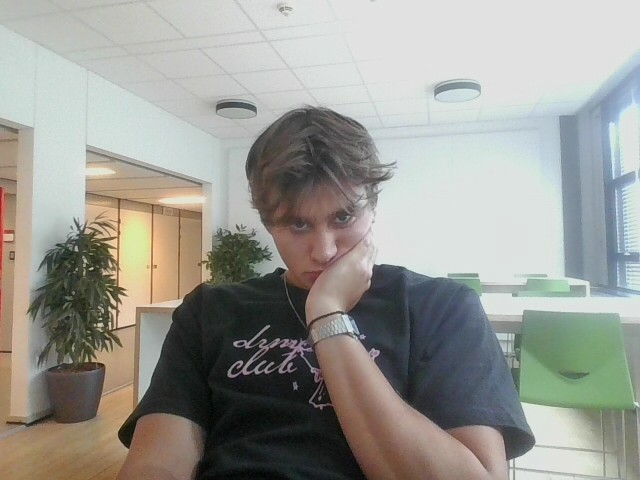

Saved settings applied for this camera open. Other notebook camera cells now apply them automatically too.


In [1]:
from pathlib import Path
import sys
import time

import cv2
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings, read_webcam_settings

APPLY_SAVED_WEBCAM_INDEX = globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)
APPLY_SAVED_WIDTH = globals().get("CAMERA_CHECK_WIDTH", 640)
APPLY_SAVED_HEIGHT = globals().get("CAMERA_CHECK_HEIGHT", 480)
APPLY_SAVED_FPS = globals().get("CAMERA_CHECK_FPS", 30)
RUN_APPLY_SAVED_CAMERA_SETTINGS_NOW = True


def apply_persisted_camera_settings_now(index=APPLY_SAVED_WEBCAM_INDEX, width=APPLY_SAVED_WIDTH, height=APPLY_SAVED_HEIGHT, fps=APPLY_SAVED_FPS):
    settings = load_camera_settings()
    if not settings:
        raise RuntimeError(f"No saved camera settings found at {SETTINGS_PATH}. Use the Live Camera Control Panel and click Save settings first.")

    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")

    try:
        print(f"Loaded persisted settings from {SETTINGS_PATH}")
        print(settings)
        apply_webcam_settings(capture, settings, verbose=True)
        print("Camera reports after applying:")
        print(read_webcam_settings(capture))
        print("Letting image settle for 1.0s...")
        time.sleep(1.0)
        frame = None
        for _ in range(20):
            ok, candidate = capture.read()
            if ok:
                frame = candidate
        if frame is None:
            raise RuntimeError("No frame received after applying settings.")
        ok, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        if ok:
            display(Image(data=encoded.tobytes(), format="jpeg"))
        print("Saved settings applied for this camera open. Other notebook camera cells now apply them automatically too.")
        return frame
    finally:
        capture.release()


if RUN_APPLY_SAVED_CAMERA_SETTINGS_NOW:
    LAST_APPLIED_SETTINGS_FRAME = apply_persisted_camera_settings_now()


## Recover Good Camera Settings

Use this if the image becomes too bright again. This version keeps auto exposure enabled and persists only the image controls you changed, such as brightness and saturation. If `LAST_CAMERA_CONTROL_SETTINGS` is available, it will save those; otherwise edit `RESTORE_CAMERA_SETTINGS` and rerun.


Using camera settings from: existing saved file /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json
Persisted settings to: /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json
{'auto_exposure': True, 'auto_wb': True, 'brightness': 102.0, 'contrast': 27.0, 'exposure': -9.5, 'fps': 30, 'gain': 96.0, 'height': 480, 'saturation': 64.0, 'webcam_index': 0, 'white_balance': 3700.0, 'width': 640}
Opened webcam index=0 backend=V4L2 mode=640x480 @ 30.0 FPS
Before applying:
{'auto_exposure_value': 3.0, 'exposure': 1250.0, 'gain': -1.0, 'auto_wb_value': 1.0, 'white_balance': 4500.0, 'brightness': 102.0, 'contrast': 27.0, 'saturation': 64.0}
Applying saved webcam settings:
  AUTO_EXPOSURE: before=3.000 requested=3.000 after=3.000 ok=True
  GAIN: before=-1.000 requested=96.000 after=-1.000 ok=False
  AUTO_WB: before=1.000 requested=1.000 after=1.000 ok=True
  BRIGHTNESS: before=102.000 requested=102.000 after=102.000 ok=Tru

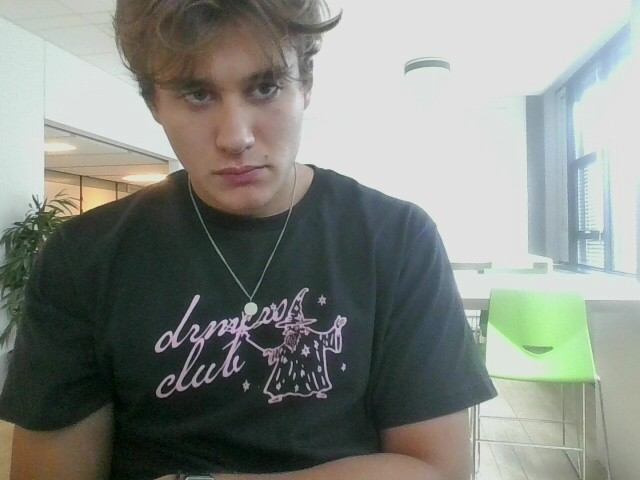

Restore complete. Other webcam cells in this notebook will now automatically apply these persisted settings.
If this still does not match the screenshot, adjust brightness/contrast/saturation in RESTORE_CAMERA_SETTINGS, then rerun this cell. Auto exposure stays ON.


In [5]:
from pathlib import Path
import sys
import time

import cv2
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings, read_webcam_settings, save_camera_settings

# If LAST_CAMERA_CONTROL_SETTINGS is gone, edit this preset to the values that looked good.
# This keeps auto exposure ON and only persists image controls such as brightness and saturation.
RESTORE_CAMERA_SETTINGS = {
    "auto_exposure": True,
    "exposure": -9.5,
    "gain": 96.0,
    "auto_wb": True,
    "white_balance": 3700.0,
    "brightness": 102.0,
    "contrast": 27.0,
    "saturation": 64.0,
    "width": globals().get("CAMERA_CHECK_WIDTH", 640),
    "height": globals().get("CAMERA_CHECK_HEIGHT", 480),
    "fps": globals().get("CAMERA_CHECK_FPS", 30),
    "webcam_index": globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0),
}

USE_KERNEL_SETTINGS_IF_AVAILABLE = True
RUN_RESTORE_CAMERA_SETTINGS_NOW = True


def _preview_frame(capture, frame_reads=25):
    frame = None
    for _ in range(frame_reads):
        ok, candidate = capture.read()
        if ok:
            frame = candidate
    if frame is None:
        raise RuntimeError("No camera frame received after applying settings.")
    ok, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
    if ok:
        display(Image(data=encoded.tobytes(), format="jpeg"))
    return frame


def recover_good_camera_settings():
    kernel_settings = globals().get("LAST_CAMERA_CONTROL_SETTINGS")
    saved_settings = load_camera_settings()

    if USE_KERNEL_SETTINGS_IF_AVAILABLE and kernel_settings:
        settings = dict(kernel_settings)
        source = "LAST_CAMERA_CONTROL_SETTINGS from this kernel"
    elif saved_settings:
        settings = dict(saved_settings)
        source = f"existing saved file {SETTINGS_PATH}"
    else:
        settings = dict(RESTORE_CAMERA_SETTINGS)
        source = "RESTORE_CAMERA_SETTINGS preset in this cell"

    settings_path = save_camera_settings(settings)
    print(f"Using camera settings from: {source}")
    print(f"Persisted settings to: {settings_path}")
    print(settings)

    index = int(settings.get("webcam_index") or globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0))
    width = int(settings.get("width") or globals().get("CAMERA_CHECK_WIDTH", 640))
    height = int(settings.get("height") or globals().get("CAMERA_CHECK_HEIGHT", 480))
    fps = int(settings.get("fps") or globals().get("CAMERA_CHECK_FPS", 30))

    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")

    try:
        try:
            backend = capture.getBackendName()
        except Exception:
            backend = "unknown"
        print(f"Opened webcam index={index} backend={backend} mode={capture.get(cv2.CAP_PROP_FRAME_WIDTH):.0f}x{capture.get(cv2.CAP_PROP_FRAME_HEIGHT):.0f} @ {capture.get(cv2.CAP_PROP_FPS):.1f} FPS")
        print("Before applying:")
        print(read_webcam_settings(capture))
        apply_webcam_settings(capture, settings, verbose=True)
        time.sleep(0.8)
        print("After applying:")
        print(read_webcam_settings(capture))
        frame = _preview_frame(capture)
        globals()["LAST_RESTORED_CAMERA_SETTINGS"] = settings
        globals()["LAST_RESTORED_CAMERA_FRAME"] = frame
        print("Restore complete. Other webcam cells in this notebook will now automatically apply these persisted settings.")
        print("If this still does not match the screenshot, adjust brightness/contrast/saturation in RESTORE_CAMERA_SETTINGS, then rerun this cell. Auto exposure stays ON.")
    finally:
        capture.release()


if RUN_RESTORE_CAMERA_SETTINGS_NOW:
    recover_good_camera_settings()


## LAB Colorpicker With Saved Camera Settings

This is the `ct.colorpicker()` workflow, but the camera is opened with the saved exposure/white-balance settings first. Press `ESC` in the OpenCV window when the mask shows only the ball, then copy/use the printed LAB values.


In [2]:
from pathlib import Path
import sys
import time

import cv2
import numpy as np

PROJECT_DIR = Path.cwd()
REPO_DIR = PROJECT_DIR
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        REPO_DIR = parent
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

for candidate in [
    REPO_DIR / "Exercises34752_week1" / "1.3",
    REPO_DIR / "Exercises34752_week1" / "1.3" / "Required_Tools" / "additions" / "exercise_camera_tools",
]:
    if (candidate / "camera_tools").is_dir() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    import camera_tools as ct
except ImportError:
    ct = None

from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings

COLORPICKER_WEBCAM_INDEX = globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)
COLORPICKER_WIDTH = globals().get("CAMERA_CHECK_WIDTH", 640)
COLORPICKER_HEIGHT = globals().get("CAMERA_CHECK_HEIGHT", 480)
COLORPICKER_FPS = globals().get("CAMERA_CHECK_FPS", 30)
RUN_COLORPICKER_NOW = True


def _setup_lab_trackbars_with_current_defaults(low=None, high=None):
    cv2.namedWindow("Trackbars", 0)
    low = np.array([0, 0, 0] if low is None else low, dtype=np.uint8)
    high = np.array([255, 255, 255] if high is None else high, dtype=np.uint8)
    for limit_name, defaults in [("MIN", low), ("MAX", high)]:
        for channel_name, default_value in zip("LAB", defaults):
            cv2.createTrackbar(f"{channel_name}_{limit_name}", "Trackbars", int(default_value), 255, lambda _value: None)


def _get_lab_trackbar_values():
    values = []
    for limit_name in ("MIN", "MAX"):
        for channel_name in "LAB":
            values.append(cv2.getTrackbarPos(f"{channel_name}_{limit_name}", "Trackbars"))
    return values


def colorpicker_with_saved_camera_settings(index=COLORPICKER_WEBCAM_INDEX, width=COLORPICKER_WIDTH, height=COLORPICKER_HEIGHT, fps=COLORPICKER_FPS):
    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")

    settings = load_camera_settings()
    try:
        try:
            backend = capture.getBackendName()
        except Exception:
            backend = "unknown"
        print(f"Colorpicker camera: OpenCV webcam index={index} backend={backend}")
        print(f"Requested mode: {width}x{height} @ {fps} FPS")
        print(f"Reported mode: {capture.get(cv2.CAP_PROP_FRAME_WIDTH):.0f}x{capture.get(cv2.CAP_PROP_FRAME_HEIGHT):.0f} @ {capture.get(cv2.CAP_PROP_FPS):.1f} FPS")

        if settings:
            print(f"Applying saved camera settings from {SETTINGS_PATH}")
            apply_webcam_settings(capture, settings, verbose=True)
            time.sleep(0.5)
        else:
            print(f"No saved camera settings found at {SETTINGS_PATH}; running colorpicker with current camera defaults.")

        low_start = globals().get("TIGHT_LOW_PURPLE", globals().get("DEFAULT_LOW_PURPLE", np.array([0, 0, 0], dtype=np.uint8)))
        high_start = globals().get("TIGHT_HIGH_PURPLE", globals().get("DEFAULT_HIGH_PURPLE", np.array([255, 255, 255], dtype=np.uint8)))
        _setup_lab_trackbars_with_current_defaults(low_start, high_start)
        print("Adjust LAB sliders until only the ball is white in 'Thresh'. Press ESC when done.")

        low_color = np.array(low_start, dtype=np.uint8)
        high_color = np.array(high_start, dtype=np.uint8)
        measured_fps = 0.0
        last_time = time.perf_counter()

        while True:
            ret, image = capture.read()
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            measured_fps = (1.0 / dt) if measured_fps == 0.0 else 0.9 * measured_fps + 0.1 * (1.0 / dt)
            if not ret:
                print("colorpicker_with_saved_camera_settings() -> Cannot read frame; ending execution.")
                break

            lab_frame = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
            l_min, a_min, b_min, l_max, a_max, b_max = _get_lab_trackbar_values()
            low_color = np.array([l_min, a_min, b_min], dtype=np.uint8)
            high_color = np.array([l_max, a_max, b_max], dtype=np.uint8)
            thresh = cv2.inRange(lab_frame, low_color, high_color)

            preview = cv2.flip(image, 1)
            cv2.putText(preview, f"{measured_fps:.1f} FPS | saved camera settings applied", (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
            cv2.putText(preview, f"{measured_fps:.1f} FPS | saved camera settings applied", (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)
            cv2.imshow("Original", preview)
            cv2.imshow("Thresh", cv2.flip(thresh, 1))

            if cv2.waitKey(20) & 0xFF == 27:
                break
    finally:
        capture.release()
        cv2.destroyAllWindows()
        for _ in range(4):
            cv2.waitKey(1)

    print("low_color =", low_color)
    print("high_color =", high_color)
    print("Paste these into TIGHT_LOW_PURPLE / TIGHT_HIGH_PURPLE, then use the wiggle controls.")
    return low_color, high_color


if RUN_COLORPICKER_NOW:
    low_green, high_green = colorpicker_with_saved_camera_settings()
    print(low_green)
    print(high_green)


Colorpicker camera: OpenCV webcam index=0 backend=V4L2
Requested mode: 640x480 @ 30 FPS
Reported mode: 640x480 @ 30.0 FPS
Applying saved camera settings from /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json
Applying saved webcam settings:
  AUTO_EXPOSURE: before=3.000 requested=3.000 after=3.000 ok=True
  GAIN: before=-1.000 requested=96.000 after=-1.000 ok=False
  AUTO_WB: before=1.000 requested=1.000 after=1.000 ok=True
  BRIGHTNESS: before=102.000 requested=102.000 after=102.000 ok=True
  CONTRAST: before=27.000 requested=27.000 after=27.000 ok=True
  SATURATION: before=64.000 requested=64.000 after=64.000 ok=True


QFontDatabase: Cannot find font directory /home/arian-sumak/miniconda3/envs/biocontrol/lib/python3.9/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/arian-sumak/miniconda3/envs/biocontrol/lib/python3.9/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/arian-sumak/miniconda3/envs/biocontrol/lib/python3.9/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/arian-sumak/miniconda3/envs/biocontrol/lib/python3.9/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to 

Adjust LAB sliders until only the ball is white in 'Thresh'. Press ESC when done.
low_color = [0 0 0]
high_color = [255 255 255]
Paste these into TIGHT_LOW_PURPLE / TIGHT_HIGH_PURPLE, then use the wiggle controls.
[0 0 0]
[255 255 255]


## Calibration And Detection Controls

Use `test_camera.ipynb` first to find tight LAB values for the purple ball. Paste those values into `TIGHT_LOW_PURPLE` and `TIGHT_HIGH_PURPLE` below; this cell widens them with `PURPLE_LAB_WIGGLE`, locks camera exposure/white balance where possible, and shows whether the mask accepts only the purple ball.


In [1]:
from pathlib import Path
import sys
import threading
import time

import cv2
import numpy as np
from IPython.display import Image, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Install ipywidgets first: %pip install ipywidgets") from exc

try:
    import pyrealsense2 as rs2
except ImportError:
    rs2 = None

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import importlib
import purple_ball_tracker
importlib.reload(purple_ball_tracker)
from purple_ball_tracker import BallTrackerConfig, find_ball_candidates, draw_debug_overlay
from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings

# Paste the tight LAB values from test_camera.ipynb here.
# First find values where the mask is mostly only the ball, then this cell adds wiggle room.
TIGHT_LOW_PURPLE = np.array([0, 136, 102], dtype=np.uint8)
TIGHT_HIGH_PURPLE = np.array([255, 255, 114], dtype=np.uint8)

# Wiggle room around the tight calibration. LAB order is [L, A, B].
# L usually needs more margin because brightness changes more than color.
PURPLE_LAB_WIGGLE = np.array([10, 4, 4], dtype=np.int16)


def widened_color_bounds(low, high, wiggle):
    low_i = np.asarray(low, dtype=np.int16)
    high_i = np.asarray(high, dtype=np.int16)
    wiggle_i = np.asarray(wiggle, dtype=np.int16)
    widened_low = np.clip(low_i - wiggle_i, 0, 255).astype(np.uint8)
    widened_high = np.clip(high_i + wiggle_i, 0, 255).astype(np.uint8)
    return widened_low, widened_high


DEFAULT_LOW_PURPLE, DEFAULT_HIGH_PURPLE = widened_color_bounds(
    TIGHT_LOW_PURPLE,
    TIGHT_HIGH_PURPLE,
    PURPLE_LAB_WIGGLE,
)

# Steady image defaults. For V4L2 webcams, exposure is often a negative log value.
# If OpenCV reports that the value did not change, use v4l2-ctl outside Python.
STEADY_LOCK_EXPOSURE = True
STEADY_WEBCAM_EXPOSURE = -6.0
STEADY_WEBCAM_GAIN = 0.0
STEADY_LOCK_WHITE_BALANCE = True
STEADY_WHITE_BALANCE = 4500.0
STEADY_SETTLE_S = 1.0
RUN_STEADY_MASK_CHECK_NOW = False

color_space = widgets.Dropdown(options=["LAB", "HSV"], value="LAB", description="Color")
low_sliders = [widgets.IntSlider(value=int(v), min=0, max=255, description=f"low {name}", continuous_update=False) for name, v in zip("LAB", DEFAULT_LOW_PURPLE)]
high_sliders = [widgets.IntSlider(value=int(v), min=0, max=255, description=f"high {name}", continuous_update=False) for name, v in zip("LAB", DEFAULT_HIGH_PURPLE)]


def apply_widened_lab_values(_=None):
    low, high = widened_color_bounds(TIGHT_LOW_PURPLE, TIGHT_HIGH_PURPLE, PURPLE_LAB_WIGGLE)
    for slider, value in zip(low_sliders, low):
        slider.value = int(value)
    for slider, value in zip(high_sliders, high):
        slider.value = int(value)
    print("Applied widened LAB calibration values:")
    print("  tight low  =", TIGHT_LOW_PURPLE)
    print("  tight high =", TIGHT_HIGH_PURPLE)
    print("  wiggle     =", PURPLE_LAB_WIGGLE)
    print("  low_color  =", low)
    print("  high_color =", high)

min_area = widgets.FloatSlider(value=80, min=1, max=2000, step=10, description="min area", continuous_update=False)
max_area = widgets.FloatSlider(value=18000, min=500, max=50000, step=500, description="max area", continuous_update=False)
min_radius = widgets.FloatSlider(value=5, min=1, max=50, step=1, description="min radius", continuous_update=False)
max_radius = widgets.FloatSlider(value=50, min=5, max=180, step=5, description="max radius", continuous_update=False)
min_circularity = widgets.FloatSlider(value=0.35, min=0, max=1, step=0.05, description="circularity", continuous_update=False)
min_solidity = widgets.FloatSlider(value=0.6, min=0, max=1, step=0.05, description="solidity", continuous_update=False)
min_fill_ratio = widgets.FloatSlider(value=0.35, min=0, max=1, step=0.05, description="fill", continuous_update=False)
min_confidence = widgets.FloatSlider(value=0.7, min=0, max=1, step=0.05, description="confidence", continuous_update=False)
morphology_kernel = widgets.IntSlider(value=3, min=1, max=15, step=2, description="morph", continuous_update=False)
tracking_distance = widgets.FloatSlider(value=300, min=10, max=400, step=10, description="track px", continuous_update=False)
recovery_after = widgets.IntSlider(value=3, min=1, max=20, step=1, description="recover", continuous_update=False)
confirmation_frames = widgets.IntSlider(value=30, min=1, max=120, step=1, description="confirm", continuous_update=False)
reacquire_confirmation_frames = widgets.IntSlider(value=3, min=1, max=30, step=1, description="reconfirm", continuous_update=False)
confirmation_distance = widgets.FloatSlider(value=300, min=10, max=400, step=10, description="confirm px", continuous_update=False)
confirmation_missed_tolerance = widgets.IntSlider(value=25, min=0, max=30, step=1, description="miss tol", continuous_update=False)

lock_exposure = widgets.Checkbox(value=STEADY_LOCK_EXPOSURE, description="Lock exposure", indent=False)
webcam_exposure = widgets.FloatText(value=STEADY_WEBCAM_EXPOSURE, description="Exposure")
webcam_gain = widgets.FloatText(value=STEADY_WEBCAM_GAIN, description="Gain")
lock_white_balance = widgets.Checkbox(value=STEADY_LOCK_WHITE_BALANCE, description="Lock white balance", indent=False)
white_balance = widgets.FloatText(value=STEADY_WHITE_BALANCE, description="White balance")
settle_seconds = widgets.FloatSlider(value=STEADY_SETTLE_S, min=0.0, max=3.0, step=0.1, description="Settle s", continuous_update=False)


def current_tracker_config():
    return BallTrackerConfig(
        color_space=color_space.value,
        low_color=tuple(slider.value for slider in low_sliders),
        high_color=tuple(slider.value for slider in high_sliders),
        min_area=min_area.value,
        max_area=max_area.value,
        min_radius=min_radius.value,
        max_radius=max_radius.value,
        min_circularity=min_circularity.value,
        min_solidity=min_solidity.value,
        min_fill_ratio=min_fill_ratio.value,
        min_confidence=min_confidence.value,
        morphology_kernel=morphology_kernel.value,
        tracking_distance_px=tracking_distance.value,
        recovery_after_frames=recovery_after.value,
        confirmation_frames=confirmation_frames.value if "confirmation_frames" in globals() else 10,
        reacquire_confirmation_frames=reacquire_confirmation_frames.value if "reacquire_confirmation_frames" in globals() else 3,
        confirmation_distance_px=confirmation_distance.value if "confirmation_distance" in globals() else 150,
        confirmation_missed_tolerance_frames=confirmation_missed_tolerance.value if "confirmation_missed_tolerance" in globals() else 10,
    )


def print_current_config(_=None):
    cfg = current_tracker_config()
    print("Detection config:")
    print(f"  color_space={cfg.color_space}")
    print("  low_color =", np.array(cfg.low_color, dtype=np.uint8))
    print("  high_color =", np.array(cfg.high_color, dtype=np.uint8))
    print(f"  area=[{cfg.min_area:.0f}, {cfg.max_area:.0f}] radius=[{cfg.min_radius:.1f}, {cfg.max_radius:.1f}]")
    print(f"  circularity>={cfg.min_circularity:.2f} solidity>={cfg.min_solidity:.2f} fill>={cfg.min_fill_ratio:.2f}")
    print(f"  confidence>={cfg.min_confidence:.2f} morph_kernel={cfg.morphology_kernel} track_px={cfg.tracking_distance_px:.0f} recovery_after={cfg.recovery_after_frames} frames")
    print(f"  confirm={cfg.confirmation_frames} first-lock frames reacquire={cfg.reacquire_confirmation_frames} frames confirm_px={cfg.confirmation_distance_px:.0f} miss_tol={cfg.confirmation_missed_tolerance_frames}")


def print_camera_check_summary():
    check = globals().get("LAST_CAMERA_CHECK")
    print("Camera check summary:")
    if not check:
        print("  No LAST_CAMERA_CHECK found. Run the Camera Helpers cell first.")
        print(f"  Current requested camera defaults: kind={globals().get('CAMERA_CHECK_KIND', 'unknown')} width={globals().get('CAMERA_CHECK_WIDTH', 'unknown')} height={globals().get('CAMERA_CHECK_HEIGHT', 'unknown')} fps={globals().get('CAMERA_CHECK_FPS', 'unknown')}")
        return
    print(f"  requested: {check['camera']} {check['requested_width']}x{check['requested_height']} @ {check['requested_fps']} FPS")
    if check.get("source_kind") == "webcam":
        print(f"  connected: OpenCV webcam index={check.get('webcam_index')} backend={check.get('backend', 'unknown')}")
        print(f"  reported mode: {check.get('actual_width', 0):.0f}x{check.get('actual_height', 0):.0f} @ {check.get('actual_fps', 0):.1f} FPS")
    else:
        print(f"  connected: RealSense format={check.get('source_format')} mode={check.get('source_width')}x{check.get('source_height')} @ {check.get('source_fps')} FPS")
    print(f"  measured loop: {check['frames_read']} frames / {check['elapsed_s']:.2f}s = {check['measured_fps']:.1f} FPS")
    print(f"  preview frame: shape={check['frame_shape']} dtype={check['frame_dtype']}")
    if check.get("measured_fps", 0) < check.get("requested_fps", 0) * 0.75:
        print("  note: measured FPS is much lower than requested; use the OpenCV window runner for faster tracking, reduce resolution, or check camera exposure/lighting.")


_mask_preview_live = globals().get("_mask_preview_live", None)


def _camera_defaults_for_preview():
    check = globals().get("LAST_CAMERA_CHECK", {})
    camera = check.get("camera", globals().get("CAMERA_CHECK_KIND", "webcam"))
    serial = globals().get("CAMERA_CHECK_SERIAL", "")
    webcam_index = check.get("webcam_index", globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)) or 0
    width = int(check.get("requested_width", globals().get("CAMERA_CHECK_WIDTH", 640)))
    height = int(check.get("requested_height", globals().get("CAMERA_CHECK_HEIGHT", 480)))
    fps = int(check.get("requested_fps", globals().get("CAMERA_CHECK_FPS", 30)))
    return camera, serial, webcam_index, width, height, fps


def _open_mask_preview_source():
    camera, serial, webcam_index, width, height, fps = _camera_defaults_for_preview()
    print(f"Opening camera for live mask preview: {camera} {width}x{height} @ {fps} FPS")
    if all(name in globals() for name in ("start_camera_source", "read_camera_frame", "close_camera_source")):
        return start_camera_source(camera=camera, serial=serial, webcam_index=webcam_index, width=width, height=height, fps=fps)

    if camera != "webcam":
        raise RuntimeError("Camera Helpers cell was not run. Fallback live preview only supports CAMERA_CHECK_KIND='webcam'.")
    capture = cv2.VideoCapture(webcam_index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {webcam_index}")
    saved_settings = load_camera_settings()
    if saved_settings:
        print(f"Applying persisted webcam settings from {SETTINGS_PATH}:")
        apply_webcam_settings(capture, saved_settings, verbose=True)
    else:
        print(f"No persisted camera settings found at {SETTINGS_PATH}; using current camera defaults.")
    return {"kind": "webcam", "capture": capture, "index": webcam_index, "width": width, "height": height, "fps": fps}


def _read_mask_preview_frame(source):
    if source.get("kind") == "webcam":
        return source["capture"].read()
    if "read_camera_frame" in globals():
        return read_camera_frame(source, timeout_ms=500)
    raise RuntimeError("No frame reader is available for this camera source.")


def _close_mask_preview_source(source):
    if not source:
        return
    if "close_camera_source" in globals():
        close_camera_source(source, silent=True)
        return
    if source.get("kind") == "webcam":
        source["capture"].release()


def _cap_prop_name(prop_id):
    names = {
        getattr(cv2, "CAP_PROP_AUTO_EXPOSURE", -1): "AUTO_EXPOSURE",
        cv2.CAP_PROP_EXPOSURE: "EXPOSURE",
        cv2.CAP_PROP_GAIN: "GAIN",
        getattr(cv2, "CAP_PROP_AUTO_WB", -2): "AUTO_WB",
        getattr(cv2, "CAP_PROP_WB_TEMPERATURE", -3): "WB_TEMPERATURE",
    }
    return names.get(prop_id, str(prop_id))


def _set_capture_prop(capture, prop_id, value):
    before = capture.get(prop_id)
    ok = capture.set(prop_id, float(value))
    time.sleep(0.05)
    after = capture.get(prop_id)
    print(f"  {_cap_prop_name(prop_id)}: before={before:.3f} requested={float(value):.3f} after={after:.3f} set_ok={ok}")
    return ok, before, after


def apply_steady_webcam_settings(source):
    capture = source["capture"]
    saved_settings = load_camera_settings()
    if saved_settings:
        print(f"Applying persisted webcam settings from {SETTINGS_PATH}:")
        apply_webcam_settings(capture, saved_settings, verbose=True)
        return

    print("No persisted camera settings found; applying this cell's steady webcam widget values:")
    if lock_exposure.value:
        if hasattr(cv2, "CAP_PROP_AUTO_EXPOSURE"):
            _set_capture_prop(capture, cv2.CAP_PROP_AUTO_EXPOSURE, 1.0)
        _set_capture_prop(capture, cv2.CAP_PROP_EXPOSURE, webcam_exposure.value)
    else:
        if hasattr(cv2, "CAP_PROP_AUTO_EXPOSURE"):
            _set_capture_prop(capture, cv2.CAP_PROP_AUTO_EXPOSURE, 3.0)
    _set_capture_prop(capture, cv2.CAP_PROP_GAIN, webcam_gain.value)
    if hasattr(cv2, "CAP_PROP_AUTO_WB"):
        _set_capture_prop(capture, cv2.CAP_PROP_AUTO_WB, 0.0 if lock_white_balance.value else 1.0)
    if lock_white_balance.value and hasattr(cv2, "CAP_PROP_WB_TEMPERATURE"):
        _set_capture_prop(capture, cv2.CAP_PROP_WB_TEMPERATURE, white_balance.value)


def _find_realsense_color_sensor(source):
    if rs2 is None:
        return None
    try:
        device = source["pipeline"].get_active_profile().get_device()
    except Exception:
        return None
    for sensor in device.query_sensors():
        try:
            name = sensor.get_info(rs2.camera_info.name).lower()
        except Exception:
            name = ""
        if "rgb" in name or "color" in name:
            return sensor
    for sensor in device.query_sensors():
        if sensor.supports(rs2.option.exposure) or sensor.supports(rs2.option.white_balance):
            return sensor
    return None


def _set_rs_option(sensor, option, label, value):
    if sensor is None or not sensor.supports(option):
        print(f"  {label}: not supported")
        return
    before = sensor.get_option(option)
    opt_range = sensor.get_option_range(option)
    clipped = min(max(float(value), opt_range.min), opt_range.max)
    sensor.set_option(option, clipped)
    time.sleep(0.05)
    after = sensor.get_option(option)
    print(f"  {label}: before={before:.3f} requested={float(value):.3f} after={after:.3f}")


def apply_steady_realsense_settings(source):
    if rs2 is None:
        print("RealSense SDK not available; cannot apply RealSense controls.")
        return
    sensor = _find_realsense_color_sensor(source)
    print("Applying steady RealSense color settings:")
    if sensor is None:
        print("  No color sensor found.")
        return
    if sensor.supports(rs2.option.enable_auto_exposure):
        _set_rs_option(sensor, rs2.option.enable_auto_exposure, "AUTO_EXPOSURE", 0.0 if lock_exposure.value else 1.0)
    if lock_exposure.value:
        _set_rs_option(sensor, rs2.option.exposure, "EXPOSURE", abs(webcam_exposure.value) if webcam_exposure.value > 0 else 100.0)
    _set_rs_option(sensor, rs2.option.gain, "GAIN", webcam_gain.value)
    if sensor.supports(rs2.option.enable_auto_white_balance):
        _set_rs_option(sensor, rs2.option.enable_auto_white_balance, "AUTO_WB", 0.0 if lock_white_balance.value else 1.0)
    if lock_white_balance.value:
        _set_rs_option(sensor, rs2.option.white_balance, "WHITE_BALANCE", white_balance.value)


def apply_steady_camera_settings(source):
    print("Lighting/exposure goal: keep room lighting fixed and lock camera auto controls before color calibration.")
    if source["kind"] == "webcam":
        apply_steady_webcam_settings(source)
    elif source["kind"] == "realsense":
        apply_steady_realsense_settings(source)
    else:
        print(f"No steady-setting implementation for source kind {source['kind']}")


def _label_image(frame, label):
    output = frame.copy()
    cv2.rectangle(output, (0, 0), (output.shape[1], 30), (0, 0, 0), -1)
    cv2.putText(output, label, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)
    return output


def _display_bgr(frame, jpeg_quality=90):
    ok, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
    if not ok:
        raise RuntimeError("Could not encode preview image.")
    display(Image(data=encoded.tobytes(), format="jpeg"))


def make_mask_calibration_panel(frame, cfg):
    candidates, mask = find_ball_candidates(frame, cfg)
    accepted = [candidate for candidate in candidates if candidate.accepted]
    rejected = [candidate for candidate in candidates if not candidate.accepted]
    segmented = cv2.bitwise_and(frame, frame, mask=mask)
    overlay = draw_debug_overlay(frame, None, candidates, mask, cfg, show_mask=False)
    mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    top = np.hstack([_label_image(frame, "Original"), _label_image(mask_bgr, "Mask")])
    bottom = np.hstack([_label_image(segmented, "Only thresholded color"), _label_image(overlay, "Accepted/rejected candidates")])
    panel = np.vstack([top, bottom])

    mask_pixels = int(cv2.countNonZero(mask))
    total_pixels = int(mask.size)
    if accepted:
        best = accepted[0]
        detail = f"best accepted center=({best.center[0]:.1f}, {best.center[1]:.1f}) radius={best.radius:.1f} area={best.area:.0f} conf={best.confidence:.2f}"
    elif candidates:
        best = candidates[0]
        detail = f"best rejected conf={best.confidence:.2f} reasons={'; '.join(best.reject_reasons)}"
    else:
        detail = "no purple candidates found"
    stats = {
        "mask_pixels": mask_pixels,
        "total_pixels": total_pixels,
        "mask_percent": 100.0 * mask_pixels / max(1, total_pixels),
        "candidates": len(candidates),
        "accepted": len(accepted),
        "rejected": len(rejected),
        "detail": detail,
    }
    return panel, stats


def show_mask_calibration_preview(frame, cfg):
    panel, stats = make_mask_calibration_panel(frame, cfg)
    print("Purple mask calibration result:")
    print(f"  mask pixels: {stats['mask_pixels']}/{stats['total_pixels']} ({stats['mask_percent']:.2f}%)")
    print(f"  candidates: total={stats['candidates']} accepted={stats['accepted']} rejected={stats['rejected']}")
    print(f"  {stats['detail']}")
    print("  Target for this step: one accepted candidate, the purple ball, with little/no background in the mask.")
    _display_bgr(panel)


def stop_steady_camera_mask_preview(_=None):
    global _mask_preview_live
    if _mask_preview_live is not None:
        _mask_preview_live["running"] = False
        _close_mask_preview_source(_mask_preview_live.get("source"))
        _mask_preview_live = None
    preview_status.value = "<span>Live mask preview stopped.</span>"


def steady_camera_mask_preview():
    global _mask_preview_live
    stop_steady_camera_mask_preview()
    source = _open_mask_preview_source()
    apply_steady_camera_settings(source)
    if settle_seconds.value > 0:
        print(f"Settling image for {settle_seconds.value:.1f}s...")
        time.sleep(settle_seconds.value)

    _mask_preview_live = {"running": True, "source": source}
    last_time = time.perf_counter()
    fps_ema = 0.0
    last_stats_print = 0.0

    def loop():
        nonlocal last_time, fps_ema, last_stats_print
        while _mask_preview_live is not None and _mask_preview_live.get("running"):
            ok, frame = _read_mask_preview_frame(source)
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            if not ok:
                preview_status.value = "<span style='color:#b00020'>Waiting for frames...</span>"
                time.sleep(0.05)
                continue

            cfg = current_tracker_config()
            panel, stats = make_mask_calibration_panel(frame, cfg)
            globals()["LAST_STEADY_FRAME"] = frame.copy()
            globals()["LAST_STEADY_CONFIG"] = cfg
            globals()["LAST_MASK_STATS"] = stats

            ok_encode, encoded = cv2.imencode(".jpg", panel, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
            if ok_encode:
                preview_image.value = encoded.tobytes()

            instant_fps = 1.0 / dt
            fps_ema = instant_fps if fps_ema == 0.0 else 0.9 * fps_ema + 0.1 * instant_fps
            preview_status.value = (
                f"<span>Live mask preview {fps_ema:.1f} FPS | "
                f"candidates={stats['candidates']} accepted={stats['accepted']} | "
                f"mask={stats['mask_percent']:.2f}% | {stats['detail']}</span>"
            )
            if now - last_stats_print > 2.0:
                last_stats_print = now
                with preview_output:
                    print(
                        f"mask={stats['mask_percent']:.2f}% candidates={stats['candidates']} "
                        f"accepted={stats['accepted']} {stats['detail']}"
                    )
            time.sleep(0.005)

    threading.Thread(target=loop, daemon=True).start()
    print("Live mask preview started. Move the sliders and watch the mask update; click Stop preview before running another camera cell.")



print_button = widgets.Button(description="Print config")
print_button.on_click(print_current_config)
apply_wiggle_button = widgets.Button(description="Apply wiggle")
apply_wiggle_button.on_click(apply_widened_lab_values)
preview_button = widgets.Button(description="Start preview", button_style="primary")
stop_preview_button = widgets.Button(description="Stop preview", button_style="danger")
preview_image = widgets.Image(format="jpeg", width=640, height=480)
preview_status = widgets.HTML(value="<span>Live mask preview stopped.</span>")
preview_output = widgets.Output()


def _preview_button_clicked(_=None):
    with preview_output:
        preview_output.clear_output(wait=True)
        steady_camera_mask_preview()


preview_button.on_click(_preview_button_clicked)
stop_preview_button.on_click(stop_steady_camera_mask_preview)

controls = widgets.VBox([
    widgets.HBox([color_space, apply_wiggle_button, print_button, preview_button, stop_preview_button]),
    widgets.HBox([widgets.VBox(low_sliders), widgets.VBox(high_sliders)]),
    widgets.HBox([widgets.VBox([min_area, max_area, min_radius, max_radius]), widgets.VBox([min_circularity, min_solidity, min_fill_ratio, min_confidence])]),
    widgets.HBox([morphology_kernel, tracking_distance, recovery_after]),
    widgets.HBox([confirmation_frames, reacquire_confirmation_frames, confirmation_distance, confirmation_missed_tolerance]),
    widgets.HBox([lock_exposure, webcam_exposure, webcam_gain]),
    widgets.HBox([lock_white_balance, white_balance, settle_seconds]),
])

print_camera_check_summary()
apply_widened_lab_values()
print_current_config()
display(controls, preview_image, preview_status, preview_output)

if RUN_STEADY_MASK_CHECK_NOW:
    _preview_button_clicked()


Camera check summary:
  No LAST_CAMERA_CHECK found. Run the Camera Helpers cell first.
  Current requested camera defaults: kind=unknown width=unknown height=unknown fps=unknown
Applied widened LAB calibration values:
  tight low  = [  0 136 102]
  tight high = [255 255 114]
  wiggle     = [10  4  4]
  low_color  = [  0 132  98]
  high_color = [255 255 118]
Detection config:
  color_space=LAB
  low_color = [  0 132  98]
  high_color = [255 255 118]
  area=[80, 18000] radius=[5.0, 50.0]
  circularity>=0.35 solidity>=0.60 fill>=0.35
  confidence>=0.70 morph_kernel=3 track_px=300 recovery_after=3 frames
  confirm=30 first-lock frames reacquire=3 frames confirm_px=300 miss_tol=25


Image(value=b'', format='jpeg', height='480', width='640')

HTML(value='<span>Live mask preview stopped.</span>')

Output()

## Live Notebook Preview

This preview is convenient for tuning. For the lowest latency, use the OpenCV window runner in the next section.


In [2]:
from pathlib import Path
import sys
import threading
import time

import cv2
import numpy as np
from IPython.display import display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Install ipywidgets first: %pip install ipywidgets") from exc

PROJECT_DIR = Path.cwd()
for parent in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (parent / "Project_final").is_dir():
        PROJECT_DIR = parent / "Project_final"
        break
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from camera_settings import SETTINGS_PATH, apply_webcam_settings, load_camera_settings
import importlib
import purple_ball_tracker
importlib.reload(purple_ball_tracker)
from purple_ball_tracker import BallTrackerConfig, PurpleBallTracker, draw_debug_overlay, draw_path

TRACKER_PREVIEW_CAMERA = globals().get("CAMERA_CHECK_KIND", "webcam")
TRACKER_PREVIEW_WEBCAM_INDEX = globals().get("CAMERA_CHECK_WEBCAM_INDEX", 0)
TRACKER_PREVIEW_WIDTH = globals().get("CAMERA_CHECK_WIDTH", 640)
TRACKER_PREVIEW_HEIGHT = globals().get("CAMERA_CHECK_HEIGHT", 480)
TRACKER_PREVIEW_FPS = globals().get("CAMERA_CHECK_FPS", 30)
RUN_TRACKER_PREVIEW_NOW = True
CROSSING_COOLDOWN_SECONDS = 5.0

_camera_live = globals().get("_camera_live", None)


def _jpeg_from_bgr(frame, quality=85):
    ok, encoded = cv2.imencode(".jpg", frame, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    if not ok:
        return b""
    return encoded.tobytes()


def _placeholder_frame(message="Click Start camera"):
    frame = np.full((TRACKER_PREVIEW_HEIGHT, TRACKER_PREVIEW_WIDTH, 3), 245, dtype=np.uint8)
    cv2.putText(frame, message, (24, TRACKER_PREVIEW_HEIGHT // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (50, 50, 50), 2, cv2.LINE_AA)
    return frame


def _default_tracker_config():
    if "current_tracker_config" in globals():
        return current_tracker_config()
    return BallTrackerConfig()


def _open_preview_webcam(index, width, height, fps):
    capture = cv2.VideoCapture(index)
    capture.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    capture.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    capture.set(cv2.CAP_PROP_FPS, fps)
    capture.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not capture.isOpened():
        raise RuntimeError(f"Could not open webcam index {index}")

    settings = load_camera_settings()
    if settings:
        print(f"Applying persisted webcam settings from {SETTINGS_PATH}")
        apply_webcam_settings(capture, settings, verbose=True)
        time.sleep(0.3)
    else:
        print(f"No saved camera settings found at {SETTINGS_PATH}; using current webcam defaults.")

    try:
        backend = capture.getBackendName()
    except Exception:
        backend = "unknown"
    print(f"Tracker preview webcam connected: index={index} backend={backend} mode={capture.get(cv2.CAP_PROP_FRAME_WIDTH):.0f}x{capture.get(cv2.CAP_PROP_FRAME_HEIGHT):.0f} @ {capture.get(cv2.CAP_PROP_FPS):.1f} FPS")
    return {"kind": "webcam", "capture": capture, "index": index, "width": width, "height": height, "fps": fps}


def _open_tracker_preview_source(camera, webcam_index, width, height, fps):
    if camera == "webcam":
        return _open_preview_webcam(webcam_index, width, height, fps)
    if "start_camera_source" in globals():
        return start_camera_source(camera=camera, webcam_index=webcam_index, width=width, height=height, fps=fps)
    raise RuntimeError("Only webcam fallback is available unless the Camera Helpers cell has been run.")


def _read_tracker_preview_frame(source):
    if source.get("kind") == "webcam":
        return source["capture"].read()
    if "read_camera_frame" in globals():
        return read_camera_frame(source, timeout_ms=500)
    raise RuntimeError("No frame reader available for this camera source.")


def _close_tracker_preview_source(source):
    if not source:
        return
    if source.get("kind") == "webcam":
        try:
            source["capture"].release()
        except Exception:
            pass
    elif "close_camera_source" in globals():
        close_camera_source(source, silent=True)


def _draw_preview_crossing_line(frame, line_ratio):
    height, width = frame.shape[:2]
    line_y = int(round(height * float(line_ratio)))
    line_y = int(np.clip(line_y, 0, height - 1))
    color = (255, 0, 255)
    cv2.line(frame, (0, line_y), (width - 1, line_y), color, 3, cv2.LINE_AA)
    cv2.putText(frame, "ball cross line", (12, max(24, line_y - 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(frame, "ball cross line", (12, max(24, line_y - 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1, cv2.LINE_AA)
    return line_y


def _draw_crossed_notice(frame):
    height, width = frame.shape[:2]
    text = "crossed"
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 1.4
    thickness = 3
    (text_width, text_height), _ = cv2.getTextSize(text, font, scale, thickness)
    x = max(12, (width - text_width) // 2)
    y = max(text_height + 20, int(height * 0.16))
    cv2.putText(frame, text, (x, y), font, scale, (0, 0, 0), thickness + 3, cv2.LINE_AA)
    cv2.putText(frame, text, (x, y), font, scale, (0, 255, 0), thickness, cv2.LINE_AA)


def _print_crossed_message(message):
    print(message, flush=True)
    terminal_stdout = getattr(sys, "__stdout__", None)
    if terminal_stdout is not None and terminal_stdout is not sys.stdout:
        terminal_stdout.write(message + "\n")
        terminal_stdout.flush()


def _accepted_box_from_detection(track, candidates):
    candidate = getattr(track, "candidate", None) if track is not None else None
    if candidate is not None and getattr(candidate, "accepted", False):
        return candidate.box, candidate.center
    for candidate in candidates:
        if getattr(candidate, "accepted", False):
            return candidate.box, candidate.center
    return None, None


def _kalman_center_from_track(track):
    if track is None:
        return None
    ball_x, ball_y = track.center
    return float(ball_x), float(ball_y)


def _trajectory_crosses_line(previous_center, current_center, line_y):
    if previous_center is None or current_center is None:
        return False
    previous_y = float(previous_center[1])
    current_y = float(current_center[1])
    if previous_y == current_y:
        return False
    return min(previous_y, current_y) <= line_y <= max(previous_y, current_y)


def _update_preview_crossing_state(track, candidates, line_y):
    if _camera_live is None:
        return False

    source = None
    message_detail = ""
    message_center = None

    box, box_center = _accepted_box_from_detection(track, candidates)
    box_on_line = False
    if box is not None and box_center is not None:
        box_x, box_y, box_width, box_height = box
        box_bottom = box_y + box_height
        box_on_line = box_y <= line_y <= box_bottom
        if box_on_line and not _camera_live.get("crossing_box_on_line", False):
            source = "box"
            message_center = box_center
            message_detail = f" box=({box_x}, {box_y}, {box_width}, {box_height})"
    _camera_live["crossing_box_on_line"] = box_on_line

    previous_kalman_center = _camera_live.get("last_kalman_center")
    current_kalman_center = _kalman_center_from_track(track)
    if current_kalman_center is None:
        _camera_live["last_kalman_center"] = None
    else:
        trajectory_crossed = _trajectory_crosses_line(previous_kalman_center, current_kalman_center, line_y)
        _camera_live["last_kalman_center"] = current_kalman_center
        if source is None and trajectory_crossed:
            source = "kalman"
            message_center = current_kalman_center
            message_detail = f" previous=({previous_kalman_center[0]:.1f}, {previous_kalman_center[1]:.1f})"

    if source is not None and message_center is not None:
        now = time.perf_counter()
        last_crossed_at = _camera_live.get("last_crossed_at", 0.0)
        if now - last_crossed_at < CROSSING_COOLDOWN_SECONDS:
            return False
        _camera_live["crossing_count"] = _camera_live.get("crossing_count", 0) + 1
        _camera_live["last_crossed_at"] = now
        _camera_live["crossed_message_until"] = now + 1.5
        ball_x, ball_y = message_center
        _print_crossed_message(f"crossed source={source} x={ball_x:.1f} y={ball_y:.1f} line_y={line_y}{message_detail}")
        return True
    return False


preview_image = widgets.Image(format="jpeg", width=TRACKER_PREVIEW_WIDTH, height=TRACKER_PREVIEW_HEIGHT)
preview_image.value = _jpeg_from_bgr(_placeholder_frame())
preview_status = widgets.HTML(value="<span>Stopped. Click Start camera.</span>")
show_mask = widgets.Checkbox(value=False, description="Mask overlay", indent=False)
show_debug = widgets.Checkbox(value=True, description="Debug overlay", indent=False)
show_cross_line = widgets.Checkbox(value=True, description="Cross line", indent=False)
cross_line_ratio = widgets.FloatSlider(value=0.84, min=0.60, max=0.95, step=0.01, description="Line y", readout_format=".2f", continuous_update=True)
start_button = widgets.Button(description="Start camera", button_style="success")
stop_button = widgets.Button(description="Stop", button_style="danger")
reset_button = widgets.Button(description="Reset tracker")


def stop_tracker_preview(_=None, silent=False):
    global _camera_live
    if _camera_live is not None:
        _camera_live["running"] = False
        _close_tracker_preview_source(_camera_live.get("source"))
        _camera_live = None
    preview_status.value = "<span>Stopped.</span>"
    if not silent:
        print("Tracker preview stopped.")


def _reset_live_tracker(_=None):
    if _camera_live and _camera_live.get("tracker"):
        _camera_live["tracker"].reset()
        _camera_live["crossing_box_on_line"] = False
        _camera_live["last_kalman_center"] = None
        _camera_live["crossing_count"] = 0
        _camera_live["last_crossed_at"] = 0.0
        _camera_live["crossed_message_until"] = 0.0
        preview_status.value = "<span>Tracker reset.</span>"


def start_tracker_preview(camera=TRACKER_PREVIEW_CAMERA, webcam_index=TRACKER_PREVIEW_WEBCAM_INDEX, width=TRACKER_PREVIEW_WIDTH, height=TRACKER_PREVIEW_HEIGHT, fps=TRACKER_PREVIEW_FPS):
    global _camera_live
    stop_tracker_preview(silent=True)
    try:
        source = _open_tracker_preview_source(camera, webcam_index, width, height, fps)
    except Exception as exc:
        preview_status.value = f"<span style='color:#b00020'>Could not start camera: {exc}</span>"
        preview_image.value = _jpeg_from_bgr(_placeholder_frame("Camera failed to start"))
        raise

    tracker = PurpleBallTracker(_default_tracker_config())
    _camera_live = {"running": True, "source": source, "tracker": tracker, "crossing_box_on_line": False, "last_kalman_center": None, "crossing_count": 0, "last_crossed_at": 0.0, "crossed_message_until": 0.0}

    def loop():
        last_time = time.perf_counter()
        fps_ema = 0.0
        while _camera_live and _camera_live.get("running"):
            ok, frame = _read_tracker_preview_frame(source)
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            if not ok:
                preview_status.value = "<span style='color:#b00020'>Waiting for frames...</span>"
                time.sleep(0.03)
                continue

            tracker.config = _default_tracker_config()
            track, candidates, mask = tracker.update(frame, dt=dt)
            if show_debug.value:
                annotated = draw_debug_overlay(frame, track, candidates, mask, tracker.config, show_mask=show_mask.value)
                annotated = draw_path(annotated, tracker.path)
            elif show_mask.value:
                annotated = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            else:
                annotated = frame

            if show_cross_line.value:
                line_y = _draw_preview_crossing_line(annotated, cross_line_ratio.value)
                _update_preview_crossing_state(track, candidates, line_y)
            elif _camera_live is not None:
                _camera_live["crossing_box_on_line"] = False
                _camera_live["last_kalman_center"] = None

            crossing_notice = _camera_live is not None and time.perf_counter() < _camera_live.get("crossed_message_until", 0.0)
            if crossing_notice:
                _draw_crossed_notice(annotated)

            preview_image.value = _jpeg_from_bgr(annotated)
            instant_fps = 1.0 / dt
            fps_ema = instant_fps if fps_ema == 0.0 else 0.9 * fps_ema + 0.1 * instant_fps
            state = track.state if track else "NO BALL"
            conf = track.confidence if track else 0.0
            confirmed = track.confirmed if track else False
            confirm_count = track.confirmation_count if track else 0
            lost = track.lost_frames if track else 0
            required_confirm = getattr(track, "required_confirmation_frames", 0) if track else tracker.config.confirmation_frames
            required_confirm = required_confirm or tracker.config.confirmation_frames
            preview_status.value = (
                f"<span>{source['kind']} frame loop {fps_ema:.1f} FPS | {state} | "
                f"confirmed={confirmed} | confirm={confirm_count}/{required_confirm} | "
                f"lost={lost}/{tracker.config.confirmation_missed_tolerance_frames} | "
                f"conf={conf:.2f} | candidates={len(candidates)} | "
                f"crossings={_camera_live.get('crossing_count', 0) if _camera_live else 0}"
                f"{' | crossed' if crossing_notice else ''}</span>"
            )
            time.sleep(0.005)

    threading.Thread(target=loop, daemon=True).start()
    print("Preview started. Use Stop before rerunning camera cells.")


start_button.on_click(lambda _=None: start_tracker_preview())
stop_button.on_click(stop_tracker_preview)
reset_button.on_click(_reset_live_tracker)

display(widgets.VBox([
    preview_image,
    widgets.HBox([start_button, stop_button, reset_button, show_mask, show_debug, show_cross_line]),
    cross_line_ratio,
    preview_status,
]))

if RUN_TRACKER_PREVIEW_NOW:
    start_tracker_preview()


Applying persisted webcam settings from /home/arian-sumak/code/DTU/Bio_Control_Exercise/Project_final/camera_control_settings.json
Applying saved webcam settings:
  AUTO_EXPOSURE: before=3.000 requested=3.000 after=3.000 ok=True
  GAIN: before=-1.000 requested=96.000 after=-1.000 ok=False
  AUTO_WB: before=1.000 requested=1.000 after=1.000 ok=True
  BRIGHTNESS: before=102.000 requested=102.000 after=102.000 ok=True
  CONTRAST: before=27.000 requested=27.000 after=27.000 ok=True
  SATURATION: before=64.000 requested=64.000 after=64.000 ok=True
Tracker preview webcam connected: index=0 backend=V4L2 mode=640x480 @ 30.0 FPS
Preview started. Use Stop before rerunning camera cells.


crossed source=kalman x=530.0 y=418.5 line_y=403 previous=(525.1, 398.2)
crossed source=kalman x=530.0 y=418.5 line_y=403 previous=(525.1, 398.2)
crossed source=box x=370.0 y=400.0 line_y=403 box=(350, 378, 40, 45)
crossed source=box x=370.0 y=400.0 line_y=403 box=(350, 378, 40, 45)
crossed source=box x=365.3 y=375.7 line_y=403 box=(340, 344, 46, 64)
crossed source=box x=365.3 y=375.7 line_y=403 box=(340, 344, 46, 64)
crossed source=box x=374.5 y=413.1 line_y=403 box=(358, 394, 33, 39)
crossed source=box x=374.5 y=413.1 line_y=403 box=(358, 394, 33, 39)
crossed source=box x=376.5 y=385.0 line_y=403 box=(359, 362, 33, 47)
crossed source=box x=376.5 y=385.0 line_y=403 box=(359, 362, 33, 47)
crossed source=kalman x=426.0 y=406.1 line_y=403 previous=(422.9, 394.4)
crossed source=kalman x=426.0 y=406.1 line_y=403 previous=(422.9, 394.4)
crossed source=kalman x=448.3 y=403.3 line_y=403 previous=(447.3, 400.0)
crossed source=kalman x=448.3 y=403.3 line_y=403 previous=(447.3, 400.0)
crossed so

## Low-Latency OpenCV Window Runner

Use this when the ball is fast. It avoids the notebook image widget and should be closer to the camera FPS. Press `ESC` to stop, `m` to toggle mask overlay, `d` to toggle debug, `r` to reset Kalman state, and `c` to print the active config.


In [6]:
def run_tracker_window(camera="realsense", serial="", webcam_index=0, width=640, height=480, fps=60):
    source = start_camera_source(camera=camera, serial=serial, webcam_index=webcam_index, width=width, height=height, fps=fps)
    tracker = PurpleBallTracker(current_tracker_config())
    window = "Purple ball tracker"
    mask_enabled = False
    debug_enabled = True
    last_time = time.perf_counter()
    fps_ema = 0.0

    try:
        while True:
            ok, frame = read_camera_frame(source, timeout_ms=500)
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            if not ok:
                continue

            tracker.config = current_tracker_config()
            track, candidates, mask = tracker.update(frame, dt=dt)
            if debug_enabled:
                display_frame = draw_debug_overlay(frame, track, candidates, mask, tracker.config, show_mask=mask_enabled)
                display_frame = draw_path(display_frame, tracker.path)
            elif mask_enabled:
                display_frame = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            else:
                display_frame = frame

            instant_fps = 1.0 / dt
            fps_ema = instant_fps if fps_ema == 0.0 else 0.9 * fps_ema + 0.1 * instant_fps
            cv2.putText(display_frame, f"{fps_ema:.1f} FPS", (display_frame.shape[1] - 110, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
            cv2.putText(display_frame, f"{fps_ema:.1f} FPS", (display_frame.shape[1] - 110, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)
            cv2.imshow(window, display_frame)

            key = cv2.waitKey(1) & 0xFF
            if key == 27:
                break
            if key == ord("m"):
                mask_enabled = not mask_enabled
            elif key == ord("d"):
                debug_enabled = not debug_enabled
            elif key == ord("r"):
                tracker.reset()
            elif key == ord("c"):
                print_current_config()
    finally:
        try:
            if source["kind"] == "realsense":
                source["pipeline"].stop()
            else:
                source["capture"].release()
        finally:
            cv2.destroyAllWindows()
            for _ in range(4):
                cv2.waitKey(1)


# For fast motion, use this instead of the widget preview.
# run_tracker_window(camera="realsense", width=640, height=480, fps=60)


## Ball Crossing Line Runner

This runner draws a horizontal line near the bottom of the live OpenCV video and prints a message whenever the tracked ball center crosses it.


In [6]:
def _draw_crossing_line(frame, line_y, label="cross line"):
    height, width = frame.shape[:2]
    y = int(np.clip(line_y, 0, height - 1))
    color = (255, 0, 255)
    cv2.line(frame, (0, y), (width - 1, y), color, 3, cv2.LINE_AA)
    cv2.putText(frame, label, (12, max(24, y - 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(frame, label, (12, max(24, y - 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1, cv2.LINE_AA)
    return y


def run_tracker_window_with_crossing_line(
    camera=None,
    webcam_index=None,
    width=None,
    height=None,
    fps=None,
    crossing_line_ratio=0.84,
    crossing_line_y=None,
    require_confirmed=True,
):
    camera = TRACKER_PREVIEW_CAMERA if camera is None else camera
    webcam_index = TRACKER_PREVIEW_WEBCAM_INDEX if webcam_index is None else webcam_index
    width = TRACKER_PREVIEW_WIDTH if width is None else width
    height = TRACKER_PREVIEW_HEIGHT if height is None else height
    fps = TRACKER_PREVIEW_FPS if fps is None else fps
    source = _open_tracker_preview_source(camera, webcam_index, width, height, fps)
    tracker = PurpleBallTracker(_default_tracker_config())
    window = "Purple ball tracker - crossing line"
    mask_enabled = False
    debug_enabled = True
    last_time = time.perf_counter()
    fps_ema = 0.0
    last_ball_side = None
    crossing_count = 0

    try:
        while True:
            ok, frame = _read_tracker_preview_frame(source)
            now = time.perf_counter()
            dt = max(1e-3, now - last_time)
            last_time = now
            if not ok:
                continue

            tracker.config = _default_tracker_config()
            track, candidates, mask = tracker.update(frame, dt=dt)
            if debug_enabled:
                display_frame = draw_debug_overlay(frame, track, candidates, mask, tracker.config, show_mask=mask_enabled)
                display_frame = draw_path(display_frame, tracker.path)
            elif mask_enabled:
                display_frame = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            else:
                display_frame = frame.copy()

            frame_height, frame_width = display_frame.shape[:2]
            line_y = crossing_line_y if crossing_line_y is not None else int(round(frame_height * crossing_line_ratio))
            line_y = _draw_crossing_line(display_frame, line_y, label="ball cross line")

            valid_track = track is not None and (track.confirmed or not require_confirmed)
            if valid_track:
                ball_x, ball_y = track.center
                current_side = -1 if ball_y < line_y else 1
                if last_ball_side is not None and current_side != last_ball_side:
                    crossing_count += 1
                    direction = "down" if current_side > last_ball_side else "up"
                    print(f"Ball crossed line {direction}: count={crossing_count}, center=({ball_x:.1f}, {ball_y:.1f}), line_y={line_y}", flush=True)
                last_ball_side = current_side
            elif track is None:
                last_ball_side = None

            instant_fps = 1.0 / dt
            fps_ema = instant_fps if fps_ema == 0.0 else 0.9 * fps_ema + 0.1 * instant_fps
            cv2.putText(display_frame, f"{fps_ema:.1f} FPS", (frame_width - 110, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
            cv2.putText(display_frame, f"{fps_ema:.1f} FPS", (frame_width - 110, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)
            cv2.imshow(window, display_frame)

            key = cv2.waitKey(1) & 0xFF
            if key == 27:
                break
            if key == ord("m"):
                mask_enabled = not mask_enabled
            elif key == ord("d"):
                debug_enabled = not debug_enabled
            elif key == ord("r"):
                tracker.reset()
                last_ball_side = None
                crossing_count = 0
            elif key == ord("c"):
                print_current_config()
    finally:
        try:
            _close_tracker_preview_source(source)
        finally:
            cv2.destroyAllWindows()
            for _ in range(4):
                cv2.waitKey(1)


# The line is at 84% of the frame height by default. Lower values move it up; higher values move it down.
# run_tracker_window_with_crossing_line()


## Quick Notes For Tuning

1. Start with the mask overlay. Tune only the color bounds until the ball is mostly white and the background is mostly black.
2. Then tune `min area`, `radius`, `circularity`, `solidity`, and `fill` until obvious false positives show red rejection labels.
3. If the ball disappears during fast throws, increase `track px`, lower `confidence` slightly, or reduce `recover` so recovery starts earlier.
4. If the tracker jumps to the wrong purple object, increase `confidence`, `circularity`, or `solidity`, and reduce `track px`.
